In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
from collections import defaultdict
from tqdm import tqdm

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer
import matplotlib.pyplot as plt
plt.style.use("~/mpl_styles/cs_paper.mplstyle")

#device = torch.device('cuda') if torch.cuda.is_available() else (torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu'))
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Training Data

Text(0.5, 1.0, 'Training Data')

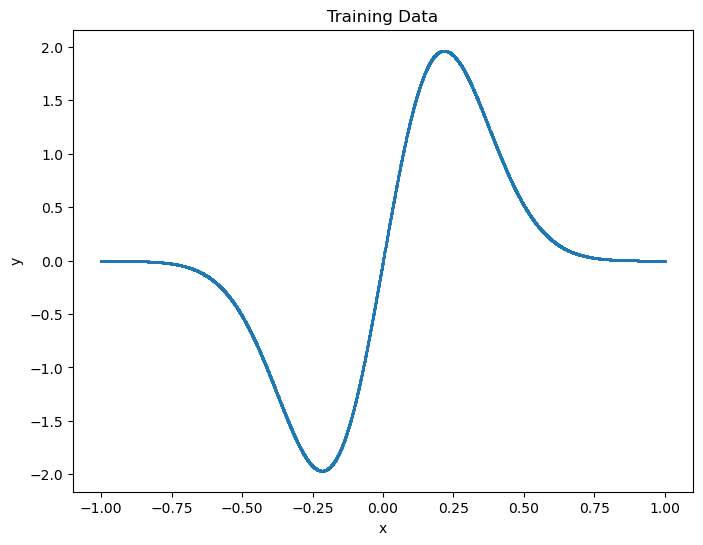

In [18]:
from torch.utils.data import DataLoader, TensorDataset

def func(x):
    return torch.exp(-10*x**2)*torch.sin(2*x)

xtrain = 2*torch.rand(10_000,1) - 1 # U[-1,1]
xtest = 2*torch.rand(10_000,1) - 1
xval = 2*torch.rand(10_000,1) - 1

ytrain = func(xtrain)
ytest = func(xtest)
yval = func(xval)

mean, std = ytrain.mean(), ytrain.std()
ytrain = (ytrain - mean) / std
ytest = (ytest - mean) / std
yval = (yval - mean) / std

batch_size = 128

train_dataset = TensorDataset(xtrain, ytrain)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(xval, yval)
val_loader = DataLoader(val_dataset, batch_size=10_000, shuffle=False)
test_dataset = TensorDataset(xtest, ytest)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# plot training data
plt.figure(figsize=(8, 6))
plt.scatter(xtrain.numpy(), ytrain.numpy(), s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Training Data')

# Define models

In [19]:
input_dim = 1
hidden_dims = [16,16,16]
output_dim = 1

mlp_adam = MLP(input_dim,hidden_dims,output_dim).to(device)
mlp_svd = MLP(input_dim,hidden_dims,output_dim).to(device)

# give both models the same initial weights
mlp_svd.load_state_dict(mlp_adam.state_dict())

<All keys matched successfully>

# Train MLP w/ Adam

In [20]:
optimizer = torch.optim.Adam(mlp_adam.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
num_epochs = 100
losses_adam = defaultdict(list)

# save untrained validation loss
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = mlp_adam(xb)
        loss = loss_fn(ypred, yb)
        losses_adam['val_init'].append(loss.item())

for epoch in tqdm(range(num_epochs)):
    epoch_losses = defaultdict(list)
    mlp_adam.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = mlp_adam(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    mlp_adam.eval()
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = mlp_adam(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
    # Save batch-wise losses
    losses_adam['train_batch'].extend(epoch_losses['train'])
    losses_adam['val_batch'].extend(epoch_losses['val'])
    for k,v in epoch_losses.items():
        losses_adam[k].append(np.mean(v))

100%|██████████| 100/100 [00:25<00:00,  3.95it/s]


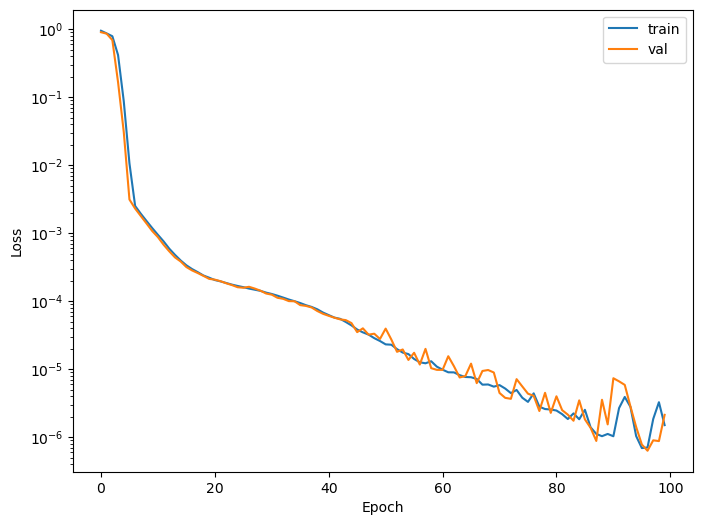

In [21]:
plt.figure(figsize=(8,6))
plt.plot(losses_adam['train'], label='train')
plt.plot(losses_adam['val'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# Train MLP w/ SVD-SGD

In [23]:
# MSE loss function
def loss_fn(pred,y):
    loss = (pred-y)**2
    loss = loss.sum(dim=-1) # shape (B,)
    return loss

lr_svd = 0.1
k_svd = batch_size // 2
rtol = 1e-3
num_epochs = 100

model_svd = FunctionalModelJac(mlp_svd,loss_fn,device)
opt_svd = SVDOptimizer(model_svd,lr=lr_svd,k=k_svd,rtol=rtol,track_svd_info=True)

losses_svd = defaultdict(list)

# save untrained validation loss
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = model_svd.evaluate(xb)
        loss = loss_fn(ypred, yb).mean()
        losses_svd['val_init'].append(loss.item())

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in tqdm(range(num_epochs)):
        epoch_losses = defaultdict(list)
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses = model_svd.loss_and_grad(batch)
            opt_svd.step()
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = model_svd.evaluate(xb)
            loss = loss_fn(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))

  0%|          | 0/100 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 100/100 [01:53<00:00,  1.14s/it]


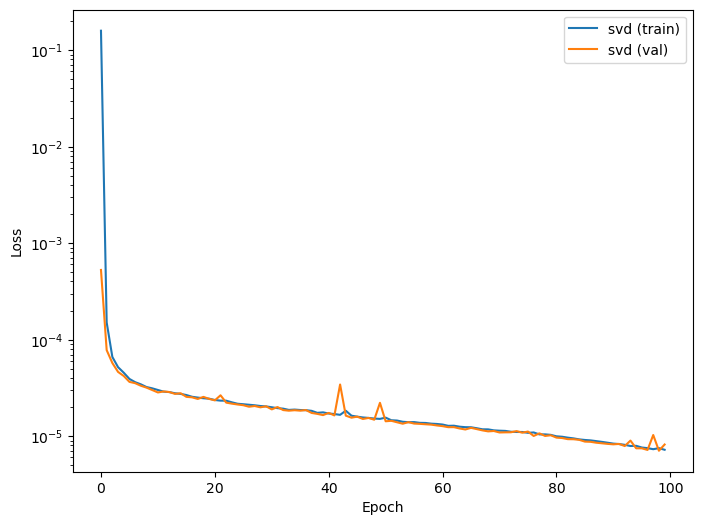

In [24]:
plt.figure(figsize=(8,6))
plt.plot(losses_svd['train'], label='svd (train)',color="C0")
plt.plot(losses_svd['val'], label='svd (val)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# Compare Adam vs SVD-SGD

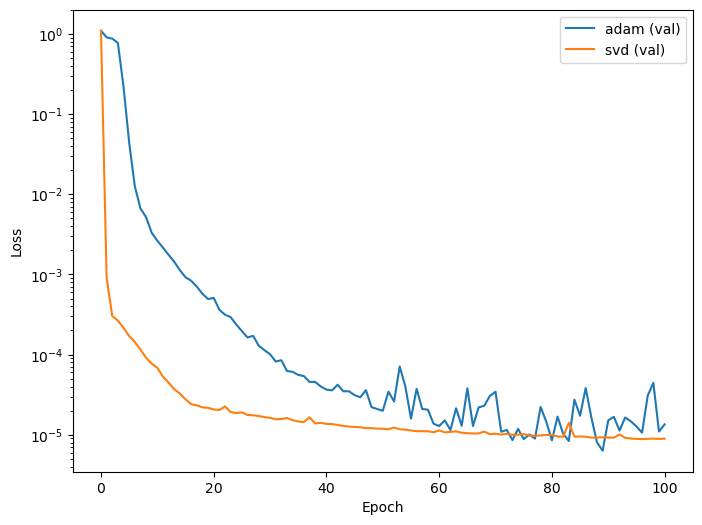

In [8]:
plt.figure(figsize=(8,6))
plt.plot(losses_adam['val_init'] + losses_adam['val'], label='adam (val)',color="C0")
plt.plot(losses_svd['val_init'] + losses_svd['val'], label='svd (val)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# Hyperparmeter scan results

In [3]:
import pickle
import pandas as pd
scan_results = pd.read_pickle("../experiment_results/toy_1d_scan/toy_1d_scan_results_df.pkl")

batch_sizes = sorted(list(set(scan_results['batch_size'].values)))
k_fracs = sorted(list(set(scan_results['k_fraction'].values)))
lrs = sorted(list(set(scan_results[scan_results['optimizer']=='SVD']['lr'].values)))

### Effect of batch size, fixed k fraction

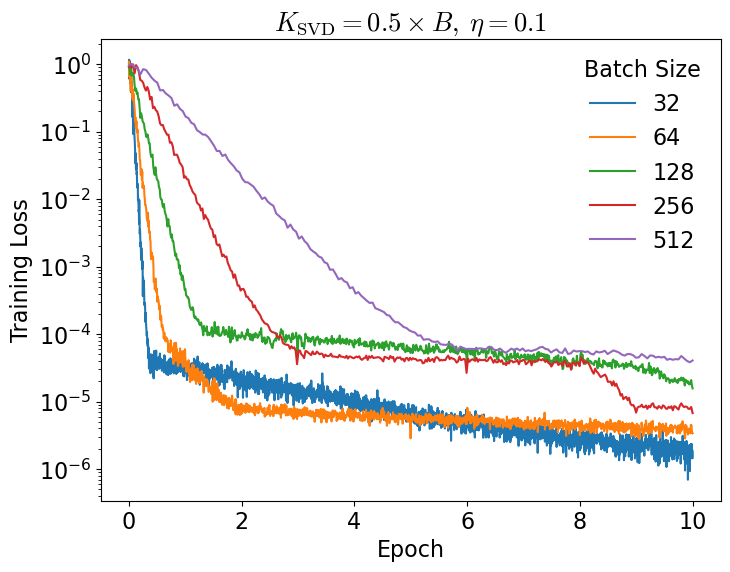

In [8]:
LR_VAL = 0.1
K_FRAC = 0.5
plt.figure(figsize=(8,6))
for bs in batch_sizes:
    k = (bs,K_FRAC,LR_VAL)
    cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL)
    res = scan_results[cut].iloc[0]
    n_epoch = len(res['losses']['val'])
    xvals = np.linspace(0,n_epoch,len(res['losses']['train_batch']))
    plt.plot(xvals, res['losses']['train_batch'], label=f'{bs}')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.yscale('log')
plt.legend(title='Batch Size')
plt.title(rf"$K_\mathrm{{SVD}} = {K_FRAC} \times B, \; \eta = {LR_VAL}$")
#plt.xlim([0,1])
plt.show()

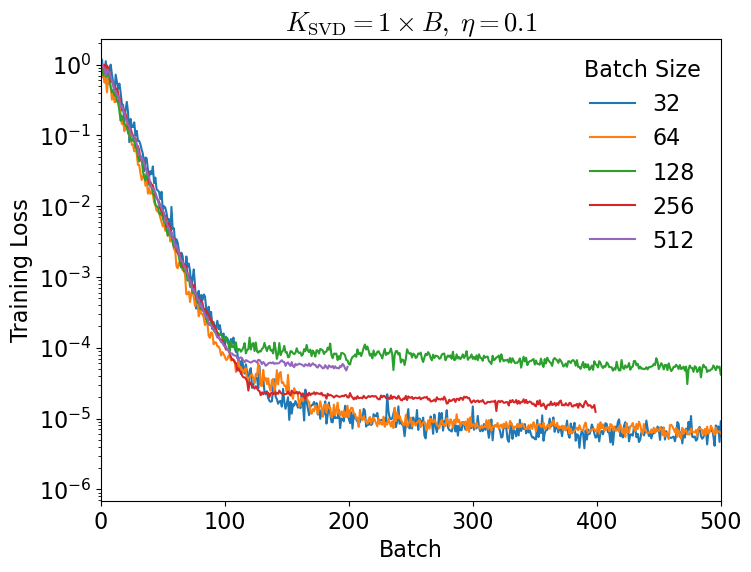

In [30]:
# look by batch
LR_VAL = 0.1
K_FRAC = 1
plt.figure(figsize=(8,6))
for bs in batch_sizes:
    k = (bs,K_FRAC,LR_VAL)
    cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL)
    res = scan_results[cut].iloc[0]
    plt.plot(res['losses']['train_batch'], label=f'{bs}')
plt.xlabel('Batch')
plt.ylabel('Training Loss')
plt.yscale('log')
plt.legend(title='Batch Size')
plt.title(rf"$K_\mathrm{{SVD}} = {K_FRAC} \times B, \; \eta = {LR_VAL}$")
plt.xlim([0,500])
plt.show()

(0.0, 500.0)

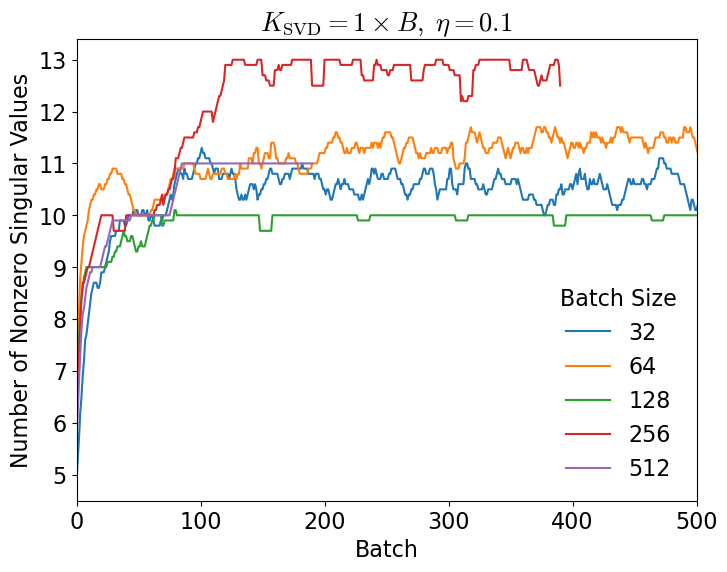

In [26]:
# look by batch
LR_VAL = 0.1
K_FRAC = 1
plt.figure(figsize=(8,6))
for bs in batch_sizes:
    k = (bs,K_FRAC,LR_VAL)
    cut = (scan_results['batch_size'] == bs) & (scan_results['k_fraction'] == K_FRAC) & (scan_results['lr'] == LR_VAL)
    res = scan_results[cut].iloc[0]
    # Calculate sliding average over 10 batches
    num_nonzero_svs = res['svd_info']['num_nonzero_svs']
    window_size = 10
    sliding_avg = np.convolve(num_nonzero_svs, np.ones(window_size)/window_size, mode='valid')
    plt.plot(sliding_avg, label=f'{bs}')
plt.xlabel('Batch')
plt.ylabel('Number of Nonzero Singular Values')
plt.legend(title='Batch Size')
plt.title(rf"$K_\mathrm{{SVD}} = {K_FRAC} \times B, \; \eta = {LR_VAL}$")
plt.xlim([0,500])
#plt.show()